# Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Load Dataset

In [6]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.shape)
print("Classes:", data.target_names)

(569, 30)
Classes: ['malignant' 'benign']


# Check Class Balance

In [7]:
pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

# Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


# Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#  Train Logistic Regression

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("done")

done


# Confusion Matrix

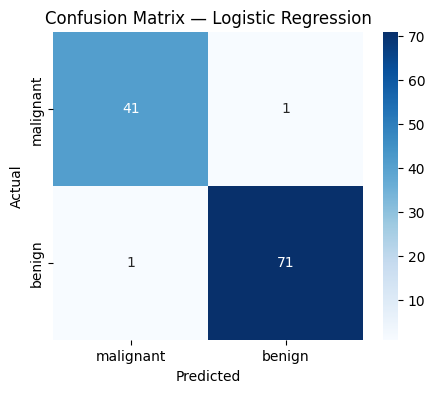

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

# Classification Report

In [26]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# ROC Curve & AUC Score

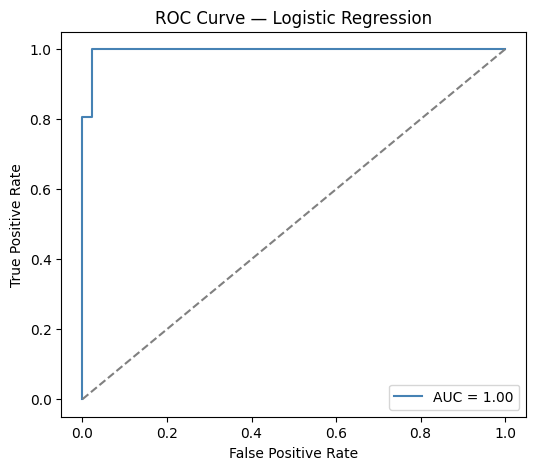

AUC Score: 0.9954


In [27]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.show()

print(f"AUC Score: {auc:.4f}")

# Handle Class Imbalance

In [28]:
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



#  Decision Tree Classifier

In [29]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)



print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



# Compare All Models

In [30]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)",
        "Decision Tree"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred), 4),
        round(accuracy_score(y_test, y_pred_balanced), 4),
        round(accuracy_score(y_test, y_pred_tree), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred_balanced), 4),
        round(f1_score(y_test, y_pred_tree), 4)
    ]
}

pd.DataFrame(results)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.9825,0.9861
1,Logistic Regression (Balanced),0.9561,0.9645
2,Decision Tree,0.9123,0.9286


# ROC Curve All Models

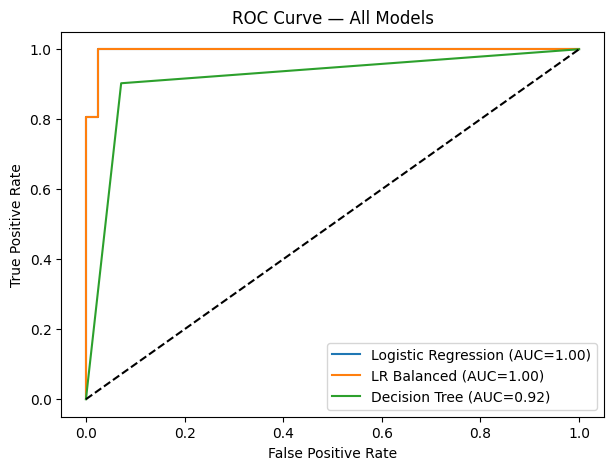

In [31]:
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]
y_prob_tree     = tree.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_balanced)
fpr3, tpr3, _ = roc_curve(y_test, y_prob_tree)

auc1 = roc_auc_score(y_test, y_prob)
auc2 = roc_auc_score(y_test, y_prob_balanced)
auc3 = roc_auc_score(y_test, y_prob_tree)

plt.figure(figsize=(7, 5))


plt.plot(fpr1, tpr1, label=f"Logistic Regression (AUC={auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"LR Balanced (AUC={auc2:.2f})")
plt.plot(fpr3, tpr3, label=f"Decision Tree (AUC={auc3:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.show()

# Save Best Model

In [32]:
import joblib

joblib.dump(model, "best_model_task4.pkl")
joblib.dump(scaler, "scaler_task4.pkl")
print("model saved")

model saved
